## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Setting to use plotly by default for plotting any chart
# pd.options.plotting.backend = "plotly"

In [2]:
## Dataset Folder
data_folder_path = "../data/"

## Read the Data File

In [3]:
dataset = pd.read_excel(data_folder_path + "Telco-Customer-Churn.xlsx")
print(dataset.shape)

(7043, 21)


## Splitting out the dataset into Train, Test and Inference Dataset which would be used for Inference Simulation

In [4]:
from sklearn.model_selection import train_test_split
rem_dataset, inference_dataset = train_test_split(dataset,test_size=0.1,random_state=30)
print(rem_dataset.shape)
print(inference_dataset.shape)

(6338, 21)
(705, 21)


In [5]:
train_dataset, test_dataset = train_test_split(rem_dataset,test_size=2*len(inference_dataset),random_state=30,stratify=rem_dataset["Churn"])
print(train_dataset.shape)
print(test_dataset.shape)

(4928, 21)
(1410, 21)


In [6]:
## Save the datasets separately
train_dataset.to_excel(data_folder_path+"train_dataset.xlsx")
test_dataset.to_excel(data_folder_path+"test_dataset.xlsx")
inference_dataset.to_excel(data_folder_path+"inference_dataset.xlsx")

In [7]:
train_dataset.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3298,1336-EZFZY,Female,0,No,No,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,83.30,No
5392,2162-FRZAA,Male,0,Yes,Yes,63,No,No phone service,DSL,No,...,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),39.35,2395.05,No
4682,0504-HHAPI,Female,1,No,No,27,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,No,Credit card (automatic),88.30,2467.75,Yes
6601,4909-JOUPP,Male,1,Yes,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),109.70,7898.45,No
3223,3082-VQXNH,Male,0,Yes,No,3,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),29.80,94.40,No
5481,8473-VUVJN,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,73.65,73.65,Yes
2986,1303-SRDOK,Female,0,Yes,Yes,55,Yes,No,Fiber optic,No,...,No,No,No,No,Two year,Yes,Credit card (automatic),69.05,3842.60,No
4645,5219-YIPTK,Female,0,Yes,No,33,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.40,3409.60,Yes
1964,2430-RRYUW,Male,0,No,No,66,Yes,No,DSL,Yes,...,No,No,No,No,One year,Yes,Mailed check,54.80,3465.70,No
6042,4750-UKWJK,Female,1,Yes,No,37,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.60,727.80,No


In [8]:
train_dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,4928.000000,4928.000000,4928.000000,4918.000000
mean,0.159903,32.179586,64.163535,2252.876281
std,0.366553,24.525388,30.214025,2257.709451
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,33.600000,382.350000
50%,0.000000,29.000000,70.050000,1377.975000
75%,0.000000,55.000000,89.650000,3712.562500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4928 entries, 3298 to 5369
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        4928 non-null   object 
 1   gender            4928 non-null   object 
 2   SeniorCitizen     4928 non-null   int64  
 3   Partner           4928 non-null   object 
 4   Dependents        4928 non-null   object 
 5   tenure            4928 non-null   int64  
 6   PhoneService      4928 non-null   object 
 7   MultipleLines     4928 non-null   object 
 8   InternetService   4928 non-null   object 
 9   OnlineSecurity    4928 non-null   object 
 10  OnlineBackup      4928 non-null   object 
 11  DeviceProtection  4928 non-null   object 
 12  TechSupport       4928 non-null   object 
 13  StreamingTV       4928 non-null   object 
 14  StreamingMovies   4928 non-null   object 
 15  Contract          4928 non-null   object 
 16  PaperlessBilling  4928 non-null   object 
 1

In [10]:
train_dataset[train_dataset["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No


In [11]:
fig = px.histogram(train_dataset, x='TotalCharges', title="Distribution of TotalCharges",nbins=20)
fig.show()

#### For all these customers the tenure is 0 and there is no total charges which means these cutomers are new and don't have a existing records for total charges. This means that filling these values with 0 would be the right thing here.

In [12]:
(train_dataset["tenure"]==0).sum()

10

## Target Variable

1 out of 4 customer churns

In [13]:
train_dataset["Churn"].value_counts(normalize=True)

Churn
No     0.736607
Yes    0.263393
Name: proportion, dtype: float64

In [14]:
fig = px.histogram(train_dataset, x='Churn', title="Distribution of Churn",color="Churn")
fig.show()

## Different Features Analysis

In [15]:
numerical_cols = train_dataset.select_dtypes(include=[np.number])
numerical_cols.describe(percentiles=[0.25,0.5,0.75,0.8,0.9,1])


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,4928.000000,4928.000000,4928.000000,4918.000000
mean,0.159903,32.179586,64.163535,2252.876281
std,0.366553,24.525388,30.214025,2257.709451
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,33.600000,382.350000
50%,0.000000,29.000000,70.050000,1377.975000
75%,0.000000,55.000000,89.650000,3712.562500
80%,0.000000,60.000000,93.900000,4431.420000
90%,1.000000,69.000000,102.145000,5970.270000
100%,1.000000,72.000000,118.750000,8684.800000


In [16]:
len(numerical_cols)

4928

In [ ]:
df_melted = pd.melt(df, var_name='Variable', value_name='Category')

# 3. Create the distribution/count plot
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df_melted, 
    x='Variable', 
    hue='Category',
    palette='Set2'
)

plt.title('Distribution of Multiple Categorical Variables')
plt.xlabel('Variable Name')
plt.ylabel('Count')
plt.show()

In [21]:
categorical_cols = list(train_dataset.select_dtypes(include=['object']).columns)
categorical_cols.remove("customerID")
categorical_cols.remove("Churn")
print(len(categorical_cols))


15


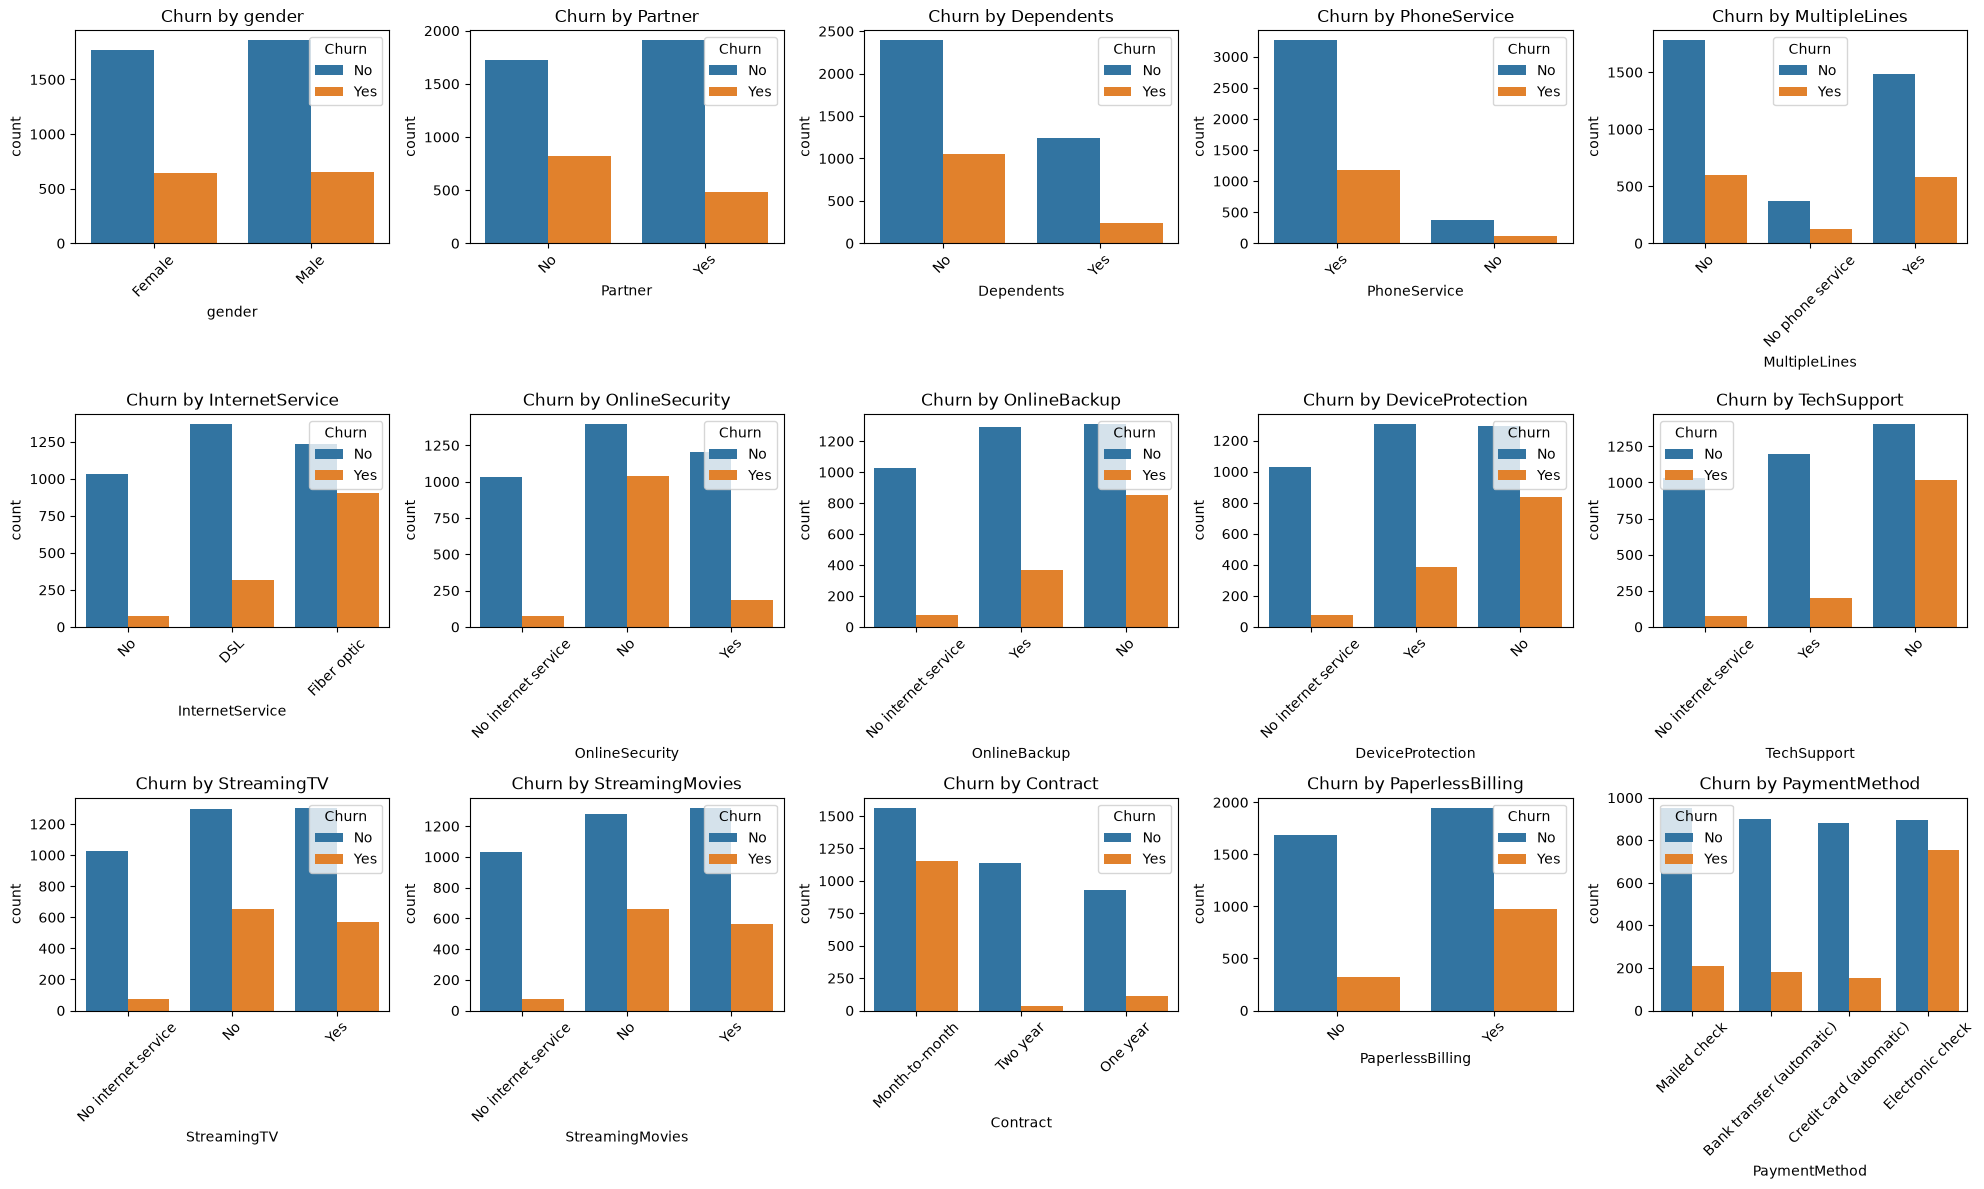

In [ ]:
import math

# 1. Dynamically calculate layout based on your actual column count
num_cols = len(categorical_cols)
grid_cols = 5
grid_rows = math.ceil(num_cols / grid_cols)

# 2. Initialize your grid
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, grid_rows * 4))
axes = axes.flatten()

# 3. Loop and plot
for i, col in enumerate(categorical_cols):
    # Pass the specific axis to the 'ax' argument
    sns.countplot(data=train_dataset, x=col, hue="Churn", ax=axes[i])
    axes[i].set_title(f"Churn by {col}")
    axes[i].tick_params(axis="x", rotation=45)

# 4. Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Based on this Analysis. We can see some of the important features are -
* Dependents (If there are dependents chances of churn decreases)
* Partners (If there are partners chances of churn decreases)
* Clients using Fibre optic Internet Service have high likelihood of churn.
* Monthly contract based clients are more prone to leave as there is no contract.
* Clients with electronic billing are more likely to leave.
* For all other service, if they are not using the service likelihood of leaving increases.


<Axes: >

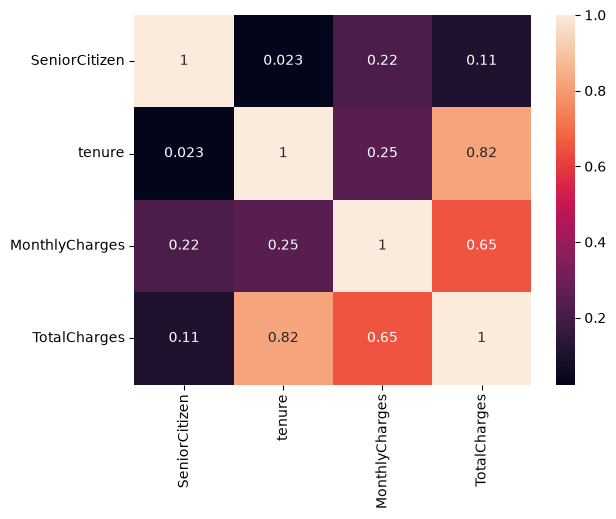

In [18]:
import seaborn as sns
sns.heatmap(numerical_cols.corr(),annot=True)